<h1>Problem Statement</h1>

Network Intrusion Detection Systems (NIDSs) have become an important component in network security infrastructure. Currently, many NIDSs are rule-based systems whose performances highly depend on their rule sets. Unfortunately, due to the huge volume of network traffic, coding the rules by security experts becomes difficult and time-consuming. Since data mining techniques can build intrusion detection models adaptively, data mining-based NIDSs have significant advantages over rule-based NIDSs .

<h1>Objective</h1>

Analyze the data set, investigate and evaluate the result and predict the overall performance. 

<h3>Exploratory Data Analysis</h3>

The purpose of this EDA is to find insights in the data which will serve us later for data preparation and transformation.

Let's start with importing the relevant modules. We will read the dataset and try to understand the data.

In [1]:
# import relevant modules
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
# ignore warnings
import warnings


#### Read the CSV file

In [2]:
# loading the dataset into our notebook
data = pd.read_csv("../input/network-intrusion/networkintrusion.csv")

Now we will print the first 5 rows of the dataset

In [3]:
data.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,private,REJ,0.0,0.0,0,0,0,0,...,10,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,anomaly
1,0,tcp,private,REJ,0.0,0.0,0,0,0,0,...,1,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,anomaly
2,2,tcp,ftp_data,SF,12983.0,0.0,0,0,0,0,...,86,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal
3,0,icmp,eco_i,SF,20.0,0.0,0,0,0,0,...,57,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,anomaly
4,1,tcp,telnet,RSTO,0.0,15.0,0,0,0,0,...,86,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,anomaly


In [4]:
data.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'num_root', 'num_shells', 'num_access_files', 'num_outbound_cmds',
       'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'class'],
      dtype='object')

We will look into the data desciption and data types to understand more about the data

In [5]:
data.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,22544.000000,2.253800e+04,2.253800e+04,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,...,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000
mean,218.859076,1.039812e+04,2.055584e+03,0.000311,0.008428,0.000710,0.105394,0.021647,0.442202,0.119899,...,193.869411,140.750532,0.608722,0.090540,0.132261,0.019638,0.097814,0.099426,0.233385,0.226683
std,1407.176612,4.728493e+05,2.122190e+04,0.017619,0.142599,0.036473,0.928428,0.150328,0.496659,7.269597,...,94.035663,111.783972,0.435688,0.220717,0.306268,0.085394,0.273139,0.281866,0.387229,0.400875
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,121.000000,15.000000,0.070000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,5.400000e+01,4.600000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,168.000000,0.920000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,2.870000e+02,6.010000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,255.000000,1.000000,0.060000,0.030000,0.010000,0.000000,0.000000,0.360000,0.170000
max,57715.000000,6.282565e+07,1.345927e+06,1.000000,3.000000,3.000000,101.000000,4.000000,1.000000,796.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22544 entries, 0 to 22543
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     22544 non-null  int64  
 1   protocol_type                22544 non-null  object 
 2   service                      22544 non-null  object 
 3   flag                         22544 non-null  object 
 4   src_bytes                    22538 non-null  float64
 5   dst_bytes                    22538 non-null  float64
 6   land                         22544 non-null  int64  
 7   wrong_fragment               22544 non-null  int64  
 8   urgent                       22544 non-null  int64  
 9   hot                          22544 non-null  int64  
 10  num_failed_logins            22544 non-null  int64  
 11  logged_in                    22544 non-null  int64  
 12  num_compromised              22544 non-null  int64  
 13  root_shell      

After observing the data we can understand that there are 4 categorical attributes and 36 numerical attributes.


<h3>Data Pre-processing</h3>

Now we will pre-process the data and prepare it for training the model. We will start the preprocessing by cleaning our data. 
For this we will first check for null values in the data.

In [7]:
data.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      6
dst_bytes                      6
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
num_root                       0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          9
srv_count                      9
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_host_rate             0
dst_host_count                 0
dst_host_s

As we can see there are few null values in dst_bytes, src_bytes, count and srv_count columns, so we will remove the null by imputing the null with the mean value for that column. We are not removing the null because the data type of these columns are float.

In [8]:
data['dst_bytes'].fillna(value=data['dst_bytes'].mean(), inplace=True)

In [9]:
data['src_bytes'].fillna(value=data['src_bytes'].mean(), inplace=True)

In [10]:
data['count'].fillna(value=data['count'].mean(), inplace=True)

In [11]:
data['srv_count'].fillna(value=data['srv_count'].mean(), inplace=True)

In [12]:
data.isnull().sum().sum()

0

Finally there are no more null data left

#### Visualization of categorical and numerical data

We will now visualize each type of data by plotting graphs and try to understand the importance of all the features.

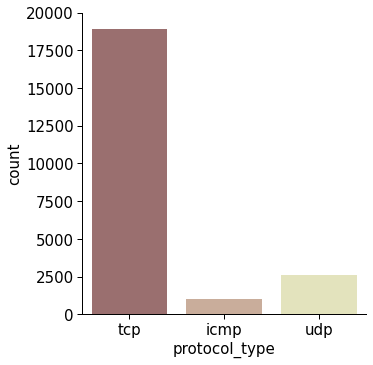

In [13]:
# Checking the counts for categorical data
sns.set_context("paper", rc={"axes.labelsize":15}) 
pl=sns.catplot(x="protocol_type", kind="count", palette="pink", data=data)
pl.set_xticklabels(fontsize=15)
pl.set_yticklabels(fontsize=15)
plt.show()

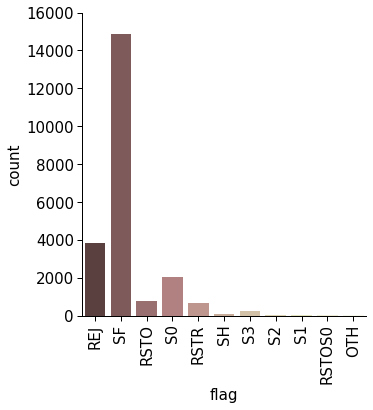

In [14]:
pl=sns.catplot(x="flag", kind="count", palette="pink", data=data)
pl.set_xticklabels(rotation=90,fontsize=15)
pl.set_yticklabels(fontsize=15)
plt.show()

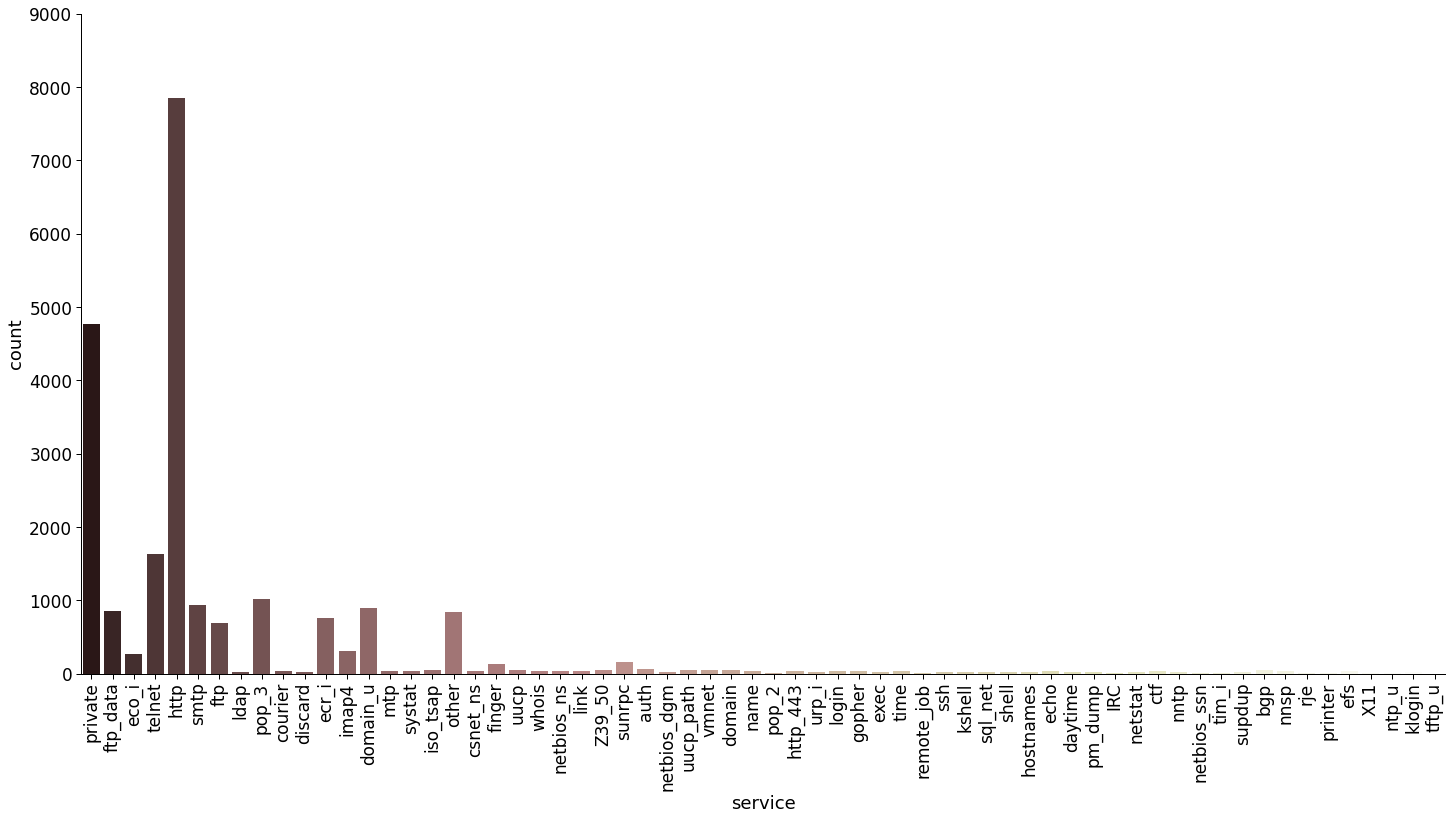

In [15]:
sns.set_context("paper", rc={"axes.labelsize":18})
pl=sns.catplot(x="service", kind="count", palette="pink",data=data, height=10, aspect=20/10)
pl.set_xticklabels(rotation=90,fontsize=17)
pl.set_yticklabels(fontsize=17)
plt.show()


We will plot a heatmap to observe the correlation among data. We will try to remove the highly correlated values after that.

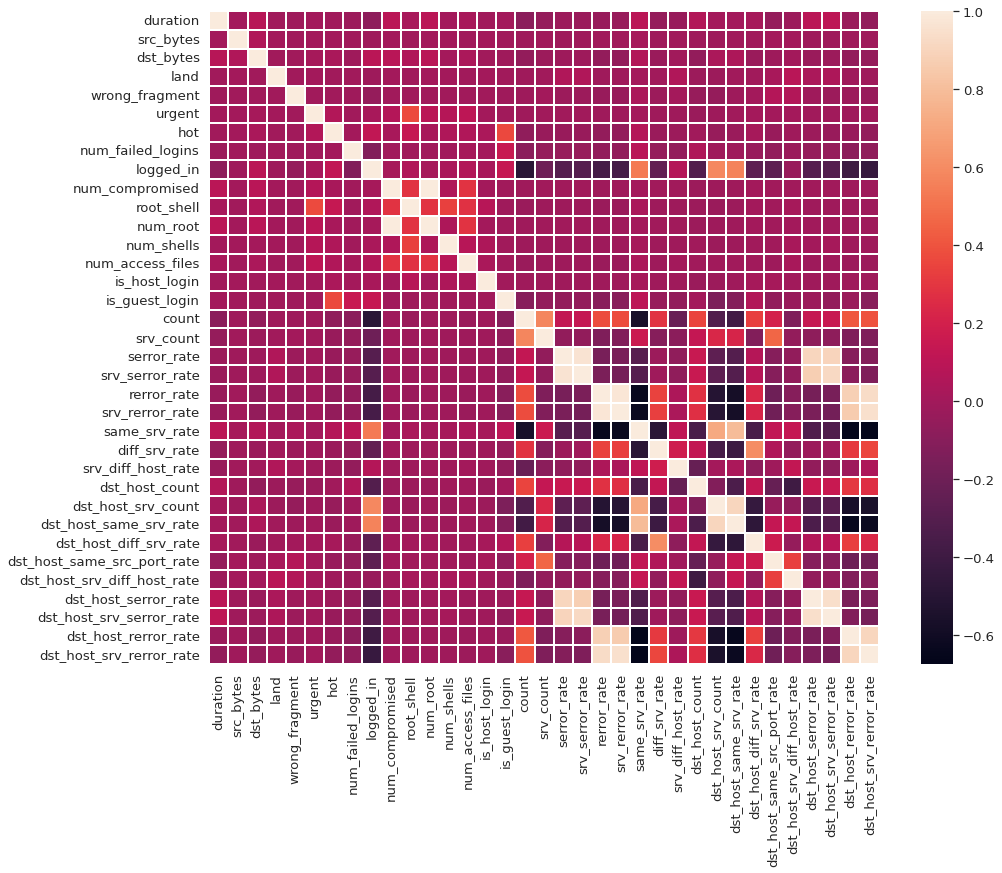

In [16]:
# Selecting the columns where there are more than 1 unique values and check for correlation
cor_data=data[[col for col in data.columns if data[col].nunique() > 1]].corr()

# Plot the heatmap for numerical data
sns.set(font_scale=1.2)
plt.figure(figsize=(15,12))
pl=sns.heatmap(cor_data,linewidths=.2)
plt.show()

From the above heatmap we observed that the columns num_root,srv_serror_rate, srv_rerror_rate, dst_host_srv_serror_rate, dst_host_serror_rate, dst_host_rerror_rate, dst_host_srv_rerror_rate, dst_host_same_srv_rate are highly correlated with other columns in the dataset. Corretaed columns are redundant for our analysis so we would ignore those values.

In [17]:
#Below variable is highly correlated and should be ignored for analysis.

data.drop('num_root',axis = 1,inplace = True)

data.drop('srv_serror_rate',axis = 1,inplace = True)

data.drop('srv_rerror_rate',axis = 1, inplace=True)

data.drop('dst_host_srv_serror_rate',axis = 1, inplace=True)

data.drop('dst_host_serror_rate',axis = 1, inplace=True)

data.drop('dst_host_rerror_rate',axis = 1, inplace=True)

data.drop('dst_host_srv_rerror_rate',axis = 1, inplace=True)

data.drop('dst_host_same_srv_rate',axis = 1, inplace=True)

In [18]:
data.shape

(22544, 32)

#### Segregation of categorical and numerical features

We are segregating the categorical and numerical columns to perform data pre-processing separately.

In [19]:
# Finding numerical columns
num_col = data._get_numeric_data().columns

# Finding categorical columns
cat_col = list(set(data.columns)-set(num_col))
cat_col.remove('class')

print('Categorical :',cat_col)
print()
print('Numerical :',num_col)

Categorical : ['flag', 'protocol_type', 'service']

Numerical : Index(['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
       'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
       'root_shell', 'num_shells', 'num_access_files', 'num_outbound_cmds',
       'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
       'dst_host_count', 'dst_host_srv_count', 'dst_host_diff_srv_rate',
       'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate'],
      dtype='object')


Saving the target attribute into another list for future analysis perpose

In [20]:
target_col=data['class']

Segregating the dataset for categorical and numerical data to perform pre-processing

In [21]:
data_cat=data[cat_col]
data_num=data[num_col]
print(data_cat.shape)
print()
print(data_num.shape)

(22544, 3)

(22544, 28)


Now we need apply One Hot encoding to categorical data. We will use pandas get_dummies method for this purpose.

After that we check the shape of the categorical data has greatly increased.

In [22]:
dummy_data=pd.get_dummies(data_cat)
dummy_data.shape

(22544, 78)

After we encode the categorical data, we will merge it with the numerical data.

We will perform normalization in the whole data after we merge.

In [23]:
data = pd.concat([dummy_data,data_num],axis=1)

#### Normalization of data

Data normalization is the process of rescaling one or more attributes to the range of 0 to 1. As our dataset contains both numerical and categorical data we will do a mix max normalization by finding the min and the max values for each column.

In [24]:
norm_data=(data-data.min())/(data.max()-data.min())


In [25]:
norm_data.describe()

,flag_OTH,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,...,serror_rate,rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate
count,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,...,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000
mean,0.000177,0.170777,0.034289,0.000089,0.029675,0.089292,0.000932,0.000665,0.011045,0.659821,...,0.102924,0.238463,0.740345,0.094074,0.098110,0.760272,0.551963,0.090540,0.132261,0.019638
std,0.013319,0.376322,0.181973,0.009419,0.169694,0.285171,0.030507,0.025787,0.104516,0.473780,...,0.295367,0.416118,0.412496,0.259138,0.253545,0.368767,0.438369,0.220717,0.306268,0.085394
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.250000,0.000000,0.000000,0.474510,0.058824,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.658824,0.010000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.250000,1.000000,0.060000,0.000000,1.000000,1.000000,0.060000,0.030000,0.010000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


After normalization we see that there is a column num_outbound_cmds for which the value is very negligible in our analysis. So we would ignore that column.

In [26]:
norm_data.drop('num_outbound_cmds',axis = 1, inplace=True)

In [27]:
norm_data.shape

(22544, 105)

<h3>Selection of Train and Test data</h3>

Selection of training and testing set is done to check our model’s performance on unseen data usually the accuracy which we print for our model is derived on validation set only. We would like to keep 80% of our total data as training set and remaining 20% as our test set. We used sklearn’s train_test_split() function to split our data frame to training and testing set.

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
X_train, X_test, y_train, y_test = train_test_split(norm_data, target_col, test_size=0.2, random_state=42)

<h2>Fitting Model</h2>

We will now train the model and check the accuracy for each model. We will use Random Forest, Decision Tree, SVm and Logistic Regression for our training. We will also print diffrent accuracy measures for each of them.

<h3>Random Forest</h3>

In [29]:
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train,y_train)


RandomForestClassifier()

In [30]:
y_pred = model.predict(X_test)
print(accuracy_score(y_test,y_pred))

0.9860279441117764


In [31]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

     anomaly       0.99      0.98      0.99      2584
      normal       0.98      0.99      0.98      1925

    accuracy                           0.99      4509
   macro avg       0.99      0.99      0.99      4509
weighted avg       0.99      0.99      0.99      4509



<h3>Decision Tree</h3>

In [32]:
from sklearn.tree import DecisionTreeClassifier
model_d = DecisionTreeClassifier(criterion="entropy", max_depth = 4)
model_d.fit(X_train, y_train)


y_pred_d = model_d.predict(X_test)
print(accuracy_score(y_test,y_pred_d))

0.9206032379685074


In [33]:
print(classification_report(y_test,y_pred_d))

              precision    recall  f1-score   support

     anomaly       0.94      0.92      0.93      2584
      normal       0.89      0.92      0.91      1925

    accuracy                           0.92      4509
   macro avg       0.92      0.92      0.92      4509
weighted avg       0.92      0.92      0.92      4509



<h3>Support Vector Machine</h3>

In [34]:
from sklearn.svm import SVC
model_s = SVC(gamma = 'scale')

model_s.fit(X_train, y_train)

y_pred_s = model_s.predict(X_test)
print(accuracy_score(y_test,y_pred_s))

0.9549789310268352


In [35]:
print(classification_report(y_test,y_pred_s))

              precision    recall  f1-score   support

     anomaly       0.96      0.97      0.96      2584
      normal       0.95      0.94      0.95      1925

    accuracy                           0.95      4509
   macro avg       0.95      0.95      0.95      4509
weighted avg       0.95      0.95      0.95      4509



<h3>Logistic Regression</h3>

In [36]:
from sklearn.linear_model import LogisticRegression
model_l = LogisticRegression(max_iter=1200000)

model_l.fit(X_train, y_train)


y_pred_l = model_l.predict(X_test)
print(accuracy_score(y_test,y_pred_l))

0.9285872699046351


In [37]:
print(classification_report(y_test,y_pred_l))

              precision    recall  f1-score   support

     anomaly       0.94      0.94      0.94      2584
      normal       0.92      0.92      0.92      1925

    accuracy                           0.93      4509
   macro avg       0.93      0.93      0.93      4509
weighted avg       0.93      0.93      0.93      4509



### Evaluate Model Performance

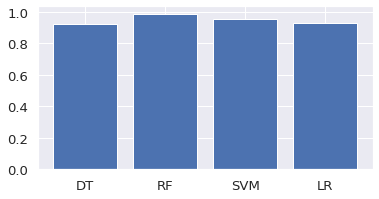

In [38]:
names = ['DT','RF','SVM','LR']
values = [0.9210,0.9855,0.9549,0.9283]
f = plt.figure(figsize=(6,3),num=10)

plt.bar(names,values)
plt.show()

From the above graph we can visualize that Random Forest has better accuracy for our analysis followed by Support Vector Machine.

### Refinement Opportunities

The model can be further improved with more data and a better algorithm that can handle biased data. Also, if we apply focal loss over these types of problem, we would get better results.